In [1]:
import torch
import onnxruntime as ort
import numpy as np
import time

from Mamba1Regressor import Mamba1ONNXRegressor, model_name, CONFIG

config = CONFIG
config.use_cuda = False

model = Mamba1ONNXRegressor(config)
# Load state dict
# model.load_state_dict(torch.load(f"trained_models/{model_name}.pt"))
model.load_state_dict(
    torch.load(
        "trained_models/experiment4/variant_1_batch_size_128_window_step_size_300_window_lengths_600_time_stretches_1.pt"
    )
)
print(
    "Number of parameters: ",
    sum(p.numel() for p in model.parameters() if p.requires_grad),
)


class ModelForwardWrapper(torch.nn.Module):
    def __init__(self, model):
        super(ModelForwardWrapper, self).__init__()
        self.model = model

    def forward(self, x, hs, inputs):
        return self.model.forward_step(x, hs, inputs)


model = ModelForwardWrapper(model)
model.eval()

x = torch.randn(1, 8)

# hs will be initialized to zeros, so do inputs
hs = torch.zeros(
    5,
    config.n_layers,
    1,
    config.d_inner,
    config.d_state,
    device=next(model.parameters()).device,
)
# inputs size would be like this
inputs = torch.zeros(
    5,
    config.n_layers,
    1,
    config.d_inner,
    config.d_conv - 1,
    device=next(model.parameters()).device,
)
print(x.shape)
print(hs.shape)
print(inputs.shape)

y, hs, inputs = model(x, hs, inputs)
print(y.shape)
print(hs.shape)
print(inputs.shape)

# onnx_program = torch.onnx.dynamo_export(model, x)
# onnx_program.save(f'trained_models/{model_name}.onnx')

torch.onnx.export(
    model,
    (torch.zeros((1, 8), dtype=torch.float), hs, inputs),
    f"trained_models/{model_name}.onnx",
    input_names=["x", "hs", "inputs"],
    output_names=["output", "hs", "inputs"],
    opset_version=18,
)

/tmp/ipykernel_2295903/1690803484.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Number of parameters:  392820
torch.Size([1, 8])
torch.Size([5, 6, 1, 64, 32])
torch.Size([5, 6, 1, 64, 3])
torch.Size([1, 20])
torch.Size([5, 6, 1, 64, 32])
torch.Size([5, 6, 1, 64, 3])


In [4]:
def measure_fps(onnx_model_path, x_shape, hs_shape, inputs_shape, num_iterations=100):
    # Load the ONNX model
    ort_session = ort.InferenceSession(onnx_model_path)

    # Generate dummy input data (same shape as during export)
    dummy_x = np.random.randn(*x_shape).astype(np.float32)
    dummy_hs = np.random.randn(*hs_shape).astype(np.float32)
    dummy_inputs = np.random.randn(*inputs_shape).astype(np.float32)

    # Warm-up runs (optional but recommended)
    for _ in range(5):
        ort_session.run(
            None, {"x": dummy_x, "hs.3": dummy_hs, "inputs.3": dummy_inputs}
        )

    # Measure FPS by running multiple iterations
    start_time = time.time()
    for _ in range(num_iterations):
        ort_session.run(
            None, {"x": dummy_x, "hs.3": dummy_hs, "inputs.3": dummy_inputs}
        )
    end_time = time.time()

    # Calculate FPS
    elapsed_time = end_time - start_time
    fps = num_iterations / elapsed_time
    return fps


# Define the path to your ONNX model
# onnx_model_path = f'trained_models/{model_name}.onnx'
onnx_model_path = f"trained_models/{model_name}.onnx"

# Define the input shape (matching the dummy input during export)
x_shape = (1, 8)  # Batch size of 1, 8 channels, length of 400
hs_shape = (5, config.n_layers, 1, config.d_inner, config.d_state)
inputs_shape = (5, config.n_layers, 1, config.d_inner, config.d_conv - 1)

# Run the FPS test
fps = measure_fps(onnx_model_path, x_shape, hs_shape, inputs_shape, num_iterations=1000)
print(f"Model FPS: {fps:.2f} iterations per second")

Model FPS: 584.61 iterations per second


In [3]:
# Compare dummy outputs from the PyTorch model and the ONNX model
dummy_x = torch.randn((1, 8), dtype=torch.float, requires_grad=False) * 10
dummy_hs = (
    torch.randn(
        (5, config.n_layers, 1, config.d_inner, config.d_state),
        dtype=torch.float,
        requires_grad=False,
    )
    * 10
)
dummy_inputs = (
    torch.randn(
        (5, config.n_layers, 1, config.d_inner, config.d_conv - 1),
        dtype=torch.float,
        requires_grad=False,
    )
    * 10
)
torch_outputs = model(dummy_x.clone(), dummy_hs.clone(), dummy_inputs.clone())
torch_outputs = [output.detach().numpy() for output in torch_outputs]
ort_session = ort.InferenceSession(onnx_model_path)
ort_outputs = ort_session.run(
    None,
    {
        "x": dummy_x.detach().numpy(),
        "hs.3": dummy_hs.detach().numpy(),
        "inputs.3": dummy_inputs.detach().numpy(),
    },
)

# Check if the outputs are close
# assert np.allclose(torch_output, ort_output, atol=1e-3)
# print(torch_output)
# print(ort_output)

for i, output in enumerate(torch_outputs):
    assert np.allclose(output, ort_outputs[i], atol=1e-1)
    print(output.shape)
    print(ort_outputs[i].shape)

    if i == 0:
        print(output)
        print(ort_outputs[i])

    print()
    print("---------------------------------------------")
    print()


# print(torch_output.shape)
# print()
# print(ort_output.shape)

(1, 20)
(1, 20)
[[-7.3424420e+02 -8.1436987e+02  3.3031125e+02  1.0906060e+03
   2.2116807e+03 -2.9099855e+04 -3.1107048e+03  2.8412095e+03
  -4.4347656e+01  3.3160969e+03  1.9858215e+03  1.2856957e+03
  -2.8839160e+02 -1.4464337e+03 -1.3170915e+02 -8.5393265e+01
  -6.2179812e+04 -4.2526223e+04 -9.2466117e+04 -7.2795289e+04]]
[[-7.3423938e+02 -8.1436127e+02  3.3031393e+02  1.0906123e+03
   2.2116802e+03 -2.9099875e+04 -3.1106902e+03  2.8412271e+03
  -4.4347870e+01  3.3160967e+03  1.9858210e+03  1.2856953e+03
  -2.8839243e+02 -1.4464330e+03 -1.3170988e+02 -8.5393806e+01
  -6.2179797e+04 -4.2526215e+04 -9.2466141e+04 -7.2795305e+04]]

---------------------------------------------

(5, 6, 1, 64, 32)
(5, 6, 1, 64, 32)

---------------------------------------------

(5, 6, 1, 64, 3)
(5, 6, 1, 64, 3)

---------------------------------------------



Mean FPS: 725.98 iterations per second
Standard deviation: 80.16 iterations per second


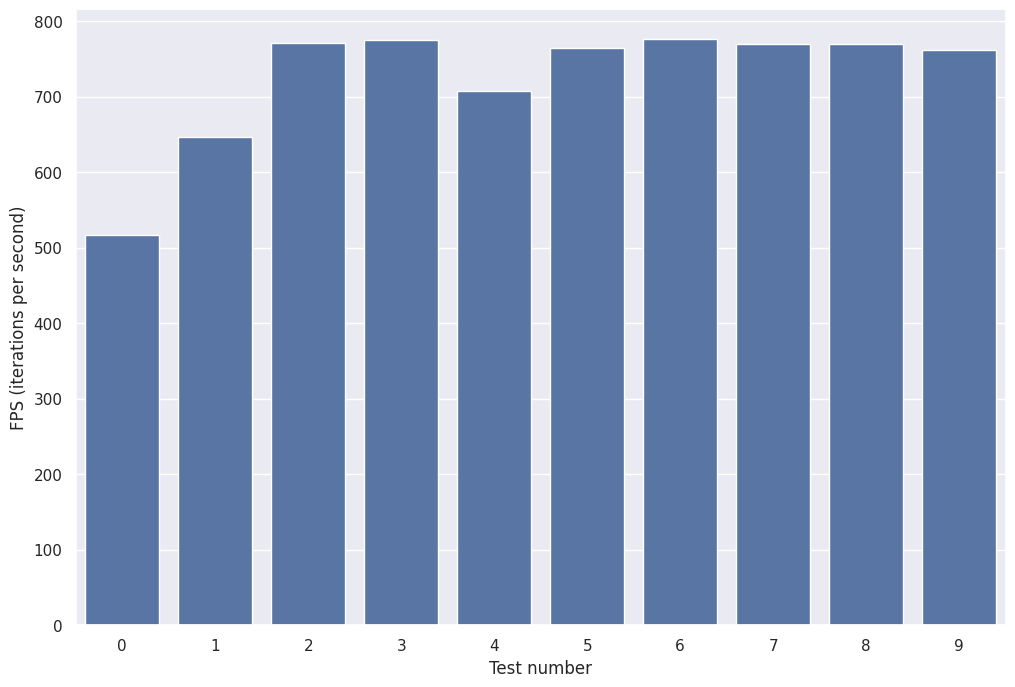

In [7]:
# Define the path to your ONNX model
# onnx_model_path = f'trained_models/{model_name}.onnx'
onnx_model_path = f"trained_models/{model_name}.onnx"

# Define the input shape (matching the dummy input during export)
x_shape = (1, 8)  # Batch size of 1, 8 channels, length of 400
hs_shape = (5, config.n_layers, 1, config.d_inner, config.d_state)
inputs_shape = (5, config.n_layers, 1, config.d_inner, config.d_conv - 1)

fpss = []

# Run the FPS test
for _ in range(10):
    fps = measure_fps(
        onnx_model_path, x_shape, hs_shape, inputs_shape, num_iterations=1000
    )
    fpss.append(fps)


# Generate statistics about the FPS
mean_fps = np.mean(fpss)
std_fps = np.std(fpss)
print(f"Mean FPS: {mean_fps:.2f} iterations per second")
print(f"Standard deviation: {std_fps:.2f} iterations per second")

# Plot the FPS values in a bar chart
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="darkgrid")

plt.figure(figsize=(12, 8))
sns.barplot(x=np.arange(len(fpss)), y=fpss)
plt.xlabel("Test number")
plt.ylabel("FPS (iterations per second)")
# plt.title("Histogram of FPS values")
plt.show()